# LDDMM: how to register a mesh to a template?

In [1]:
import shutil
import string

import numpy as np
import pyvista as pv

import polpo.utils as putils
from polpo.mesh.deformetrica import LddmmMetric, Point
from polpo.mesh.generation.blob import create_blob
from polpo.plot.pyvista import RegisteredMeshesGifPlotter
from polpo.preprocessing.mesh.registration import RigidAlignment

[KeOps] Warning : CUDA was detected, but driver API could not be initialized. Switching to CPU only.


In [2]:
RECOMPUTE = False  # in case registration has already been run

# NB: fix seed before setting it to False
np.random.seed(42)

STATIC_VIZ = True

if STATIC_VIZ:
    pv.set_jupyter_backend("static")

In [3]:
OUTPUTS_DIR = putils.get_results_path() / "registration_blob_example"

if OUTPUTS_DIR.exists() and RECOMPUTE:
    shutil.rmtree(OUTPUTS_DIR)

OUTPUTS_DIR

PosixPath('/home/luisfpereira/.polpo/results/registration_blob_example')

## Generate meshes

In [4]:
bump_amp = 0.2

raw_meshes = [
    create_blob(resolution=10, bump_amp=bump_amp, n_bumps=5, smoothing_iter=10)
    for _ in range(2)
]

raw_meshes[0].points.shape

(82, 3)

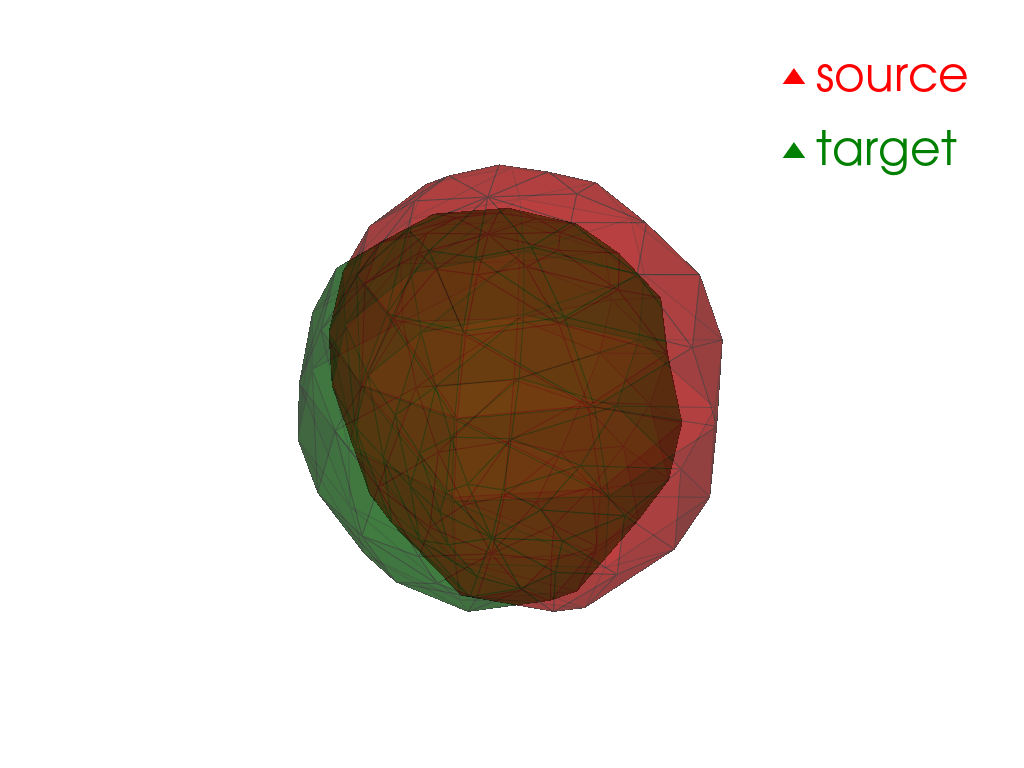

In [5]:
meshes_ = raw_meshes
pl = pv.Plotter(border=False)

pl.add_mesh(
    meshes_[0],
    show_edges=True,
    color="red",
    opacity=0.5,
    label="source",
)
pl.add_mesh(
    meshes_[1],
    show_edges=True,
    color="green",
    opacity=0.5,
    label="target",
)
pl.add_legend()

pl.show()

## Preprocessing

As we can see in the visualization, meshes are not rigid aligned. Preprocessing takes care of this kind of details, before applying LDDMM.

In [6]:
prep_pipe = RigidAlignment(known_correspondences=True)

meshes = prep_pipe(raw_meshes)

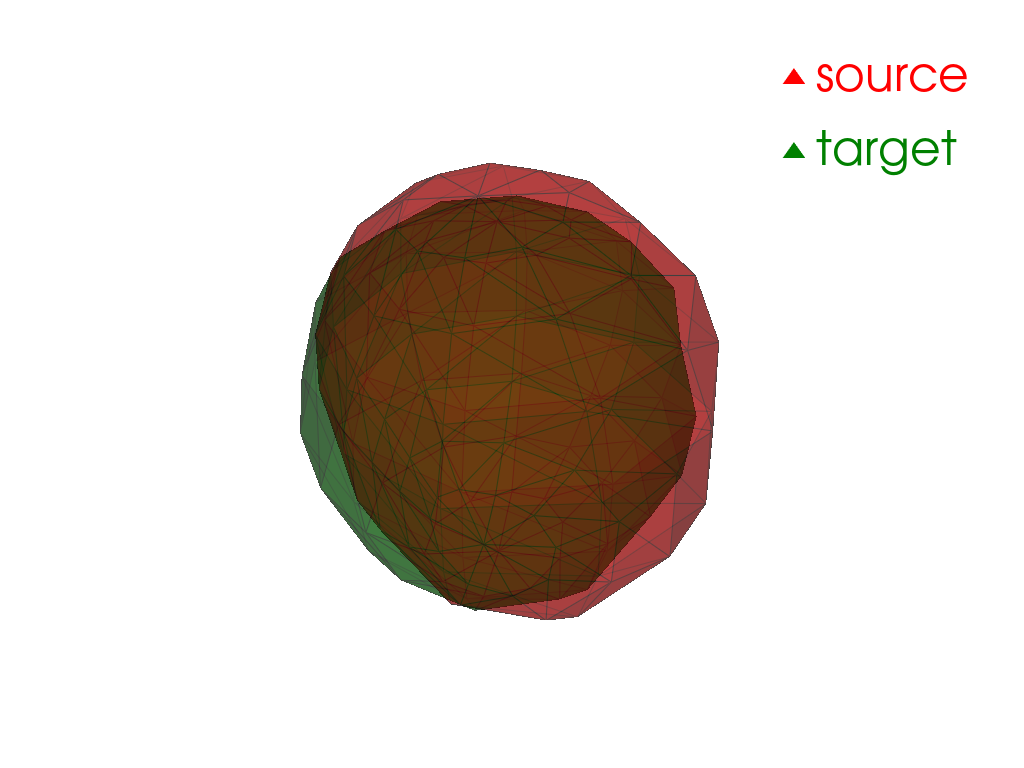

In [7]:
meshes_ = meshes
pl = pv.Plotter(border=False)

pl.add_mesh(
    meshes_[0],
    show_edges=True,
    color="red",
    opacity=0.5,
    label="source",
)
pl.add_mesh(
    meshes_[1],
    show_edges=True,
    color="green",
    opacity=0.5,
    label="target",
)

pl.add_legend()

pl.show()

## Registration

In [8]:
kernel_width = 2 * bump_amp
registration_kwargs = dict(
    kernel_width=kernel_width,
    regularisation=1.0,
    max_iter=2000,
    freeze_control_points=False,
    metric="varifold",
    tol=1e-16,
    attachment_kernel_width=bump_amp,
)

metric = LddmmMetric(OUTPUTS_DIR, **registration_kwargs)

In [9]:
points = [
    Point(id_=string.ascii_uppercase[index], pv_surface=mesh, dirname=metric.meshes_dir)
    for index, mesh in enumerate(meshes)
]

base_point, point = points

In [10]:
# NB: computational time changes very little for res \in [10, 20]
vec = metric.log(point, base_point)

## Visualization

### Template and control points

In [11]:
control_points = vec.control_points(as_path=False)

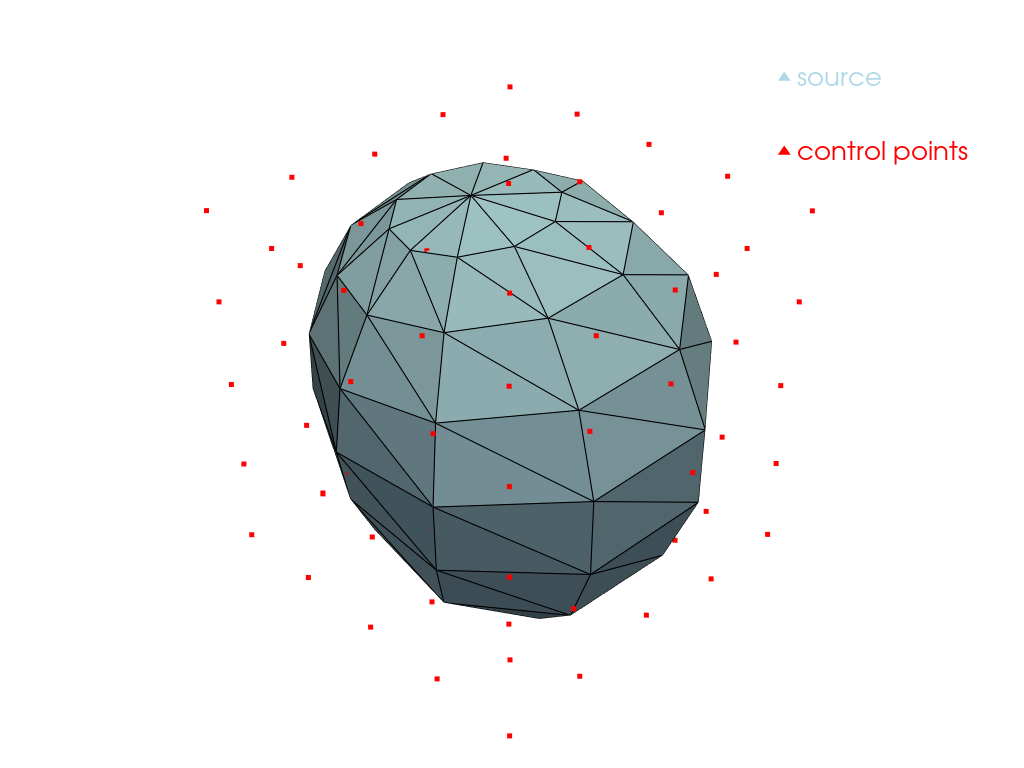

In [12]:
pl = pv.Plotter()

pl.add_mesh(
    vec.base_point.as_pv(),
    show_edges=True,
    label="source",
)

pl.add_points(
    pv.PolyData(control_points),
    color="red",
    label="control points",
)

pl.add_legend()

pl.show()

### Target and reconstructed meshes

In [13]:
reconstructed = vec.reconstructed()

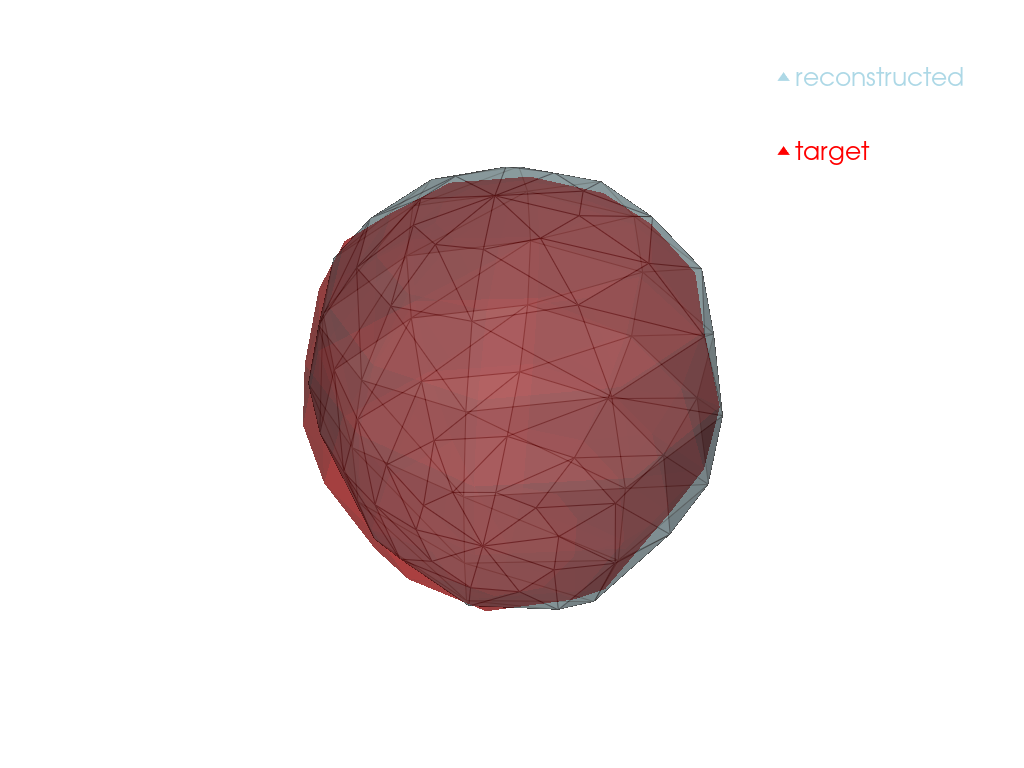

In [14]:
pl = pv.Plotter()

pl.add_mesh(
    reconstructed.as_pv(),
    show_edges=True,
    opacity=0.5,
    label="reconstructed",
)
pl.add_mesh(
    point.as_pv(),
    opacity=0.5,
    color="red",
    label="target",
)
pl.add_legend()

pl.show()

### Flow

In [15]:
flow_meshes = vec.flow()

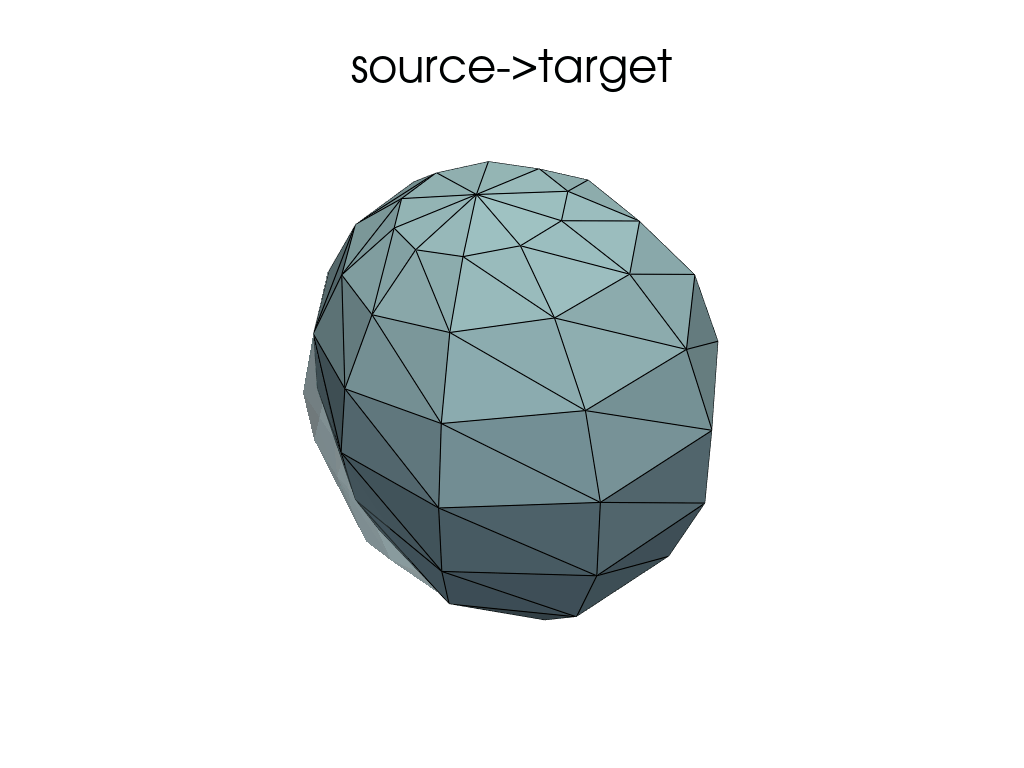

In [16]:
pl = RegisteredMeshesGifPlotter()

pl.add_mesh(reconstructed.as_pv(), opacity=0.5)
# TODO: check bug with ordering
pl.add_title("source->target")

pl.add_meshes(flow_meshes)


pl.close()

pl.show()

In [17]:
np.amax(np.abs(flow_meshes[-1].points - vec.reconstructed().as_pv().points))

np.float64(0.0)

### Reconstruct flow by shooting

In [18]:
point_ = metric.exp(vec, point)

In [19]:
flow_meshes_ = point_.flow()

In [20]:
[
    np.amax(np.abs(flow_meshes_[-1].points - point_.as_pv().points)),
    np.amax(point.as_pv().points - point_.as_pv().points),
]

[np.float64(0.0), np.float64(0.09675066165098034)]

In [21]:
diffs = [
    np.abs(np.amax(mesh.points - cmp_mesh.points))
    for mesh, cmp_mesh in zip(flow_meshes, flow_meshes_)
]

# TODO: identify origin of differences
np.amax(diffs)

np.float64(0.2667158544063568)

## Further reading

* [LDDMM: how to estimate a deterministic atlas?](./deformetrica_deterministic_atlas.ipynb)

* [LDDMM: how to do regression?](./lddmm_regression.ipynb)